Loaded images shape: (2767, 128, 128, 3)
Loaded labels shape: (2767,)
Training shape: (2213, 128, 128, 3)
Testing shape: (554, 128, 128, 3)
Flattened input shape: (2213, 49152)
PCA reduced shape: (2213, 150)
Explained variance ratio: 0.7413055186383825
KNN training complete.

Test Accuracy: 0.8809

Classification Report:
                  precision    recall  f1-score   support

   Hariana Front       0.95      0.82      0.88       175
    Hariana Left       0.83      0.95      0.89        61
Red_Sindhi Front       1.00      0.86      0.93        43
 Red_Sindhi Left       0.93      0.97      0.95        29
   Sahiwal Front       1.00      0.85      0.92        54
    Sahiwal Left       0.86      0.95      0.90        44
 Tharparkar Left       0.75      0.98      0.85        54
Tharparker Front       0.81      0.85      0.83        94

        accuracy                           0.88       554
       macro avg       0.89      0.90      0.89       554
    weighted avg       0.89      0.88

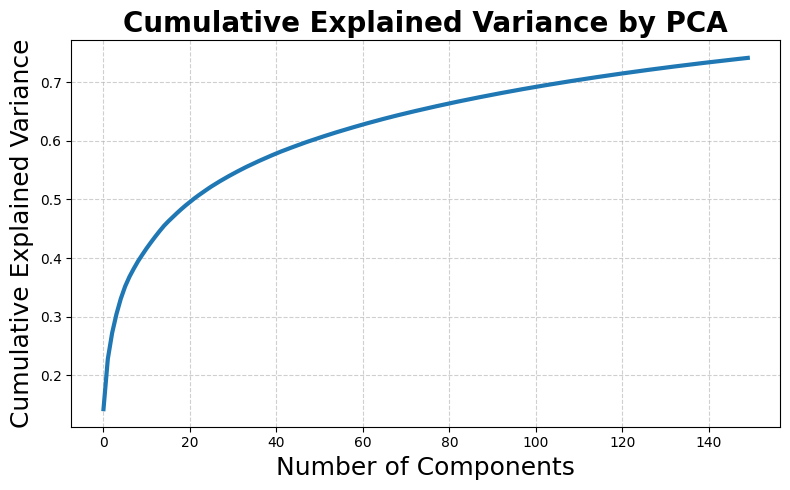

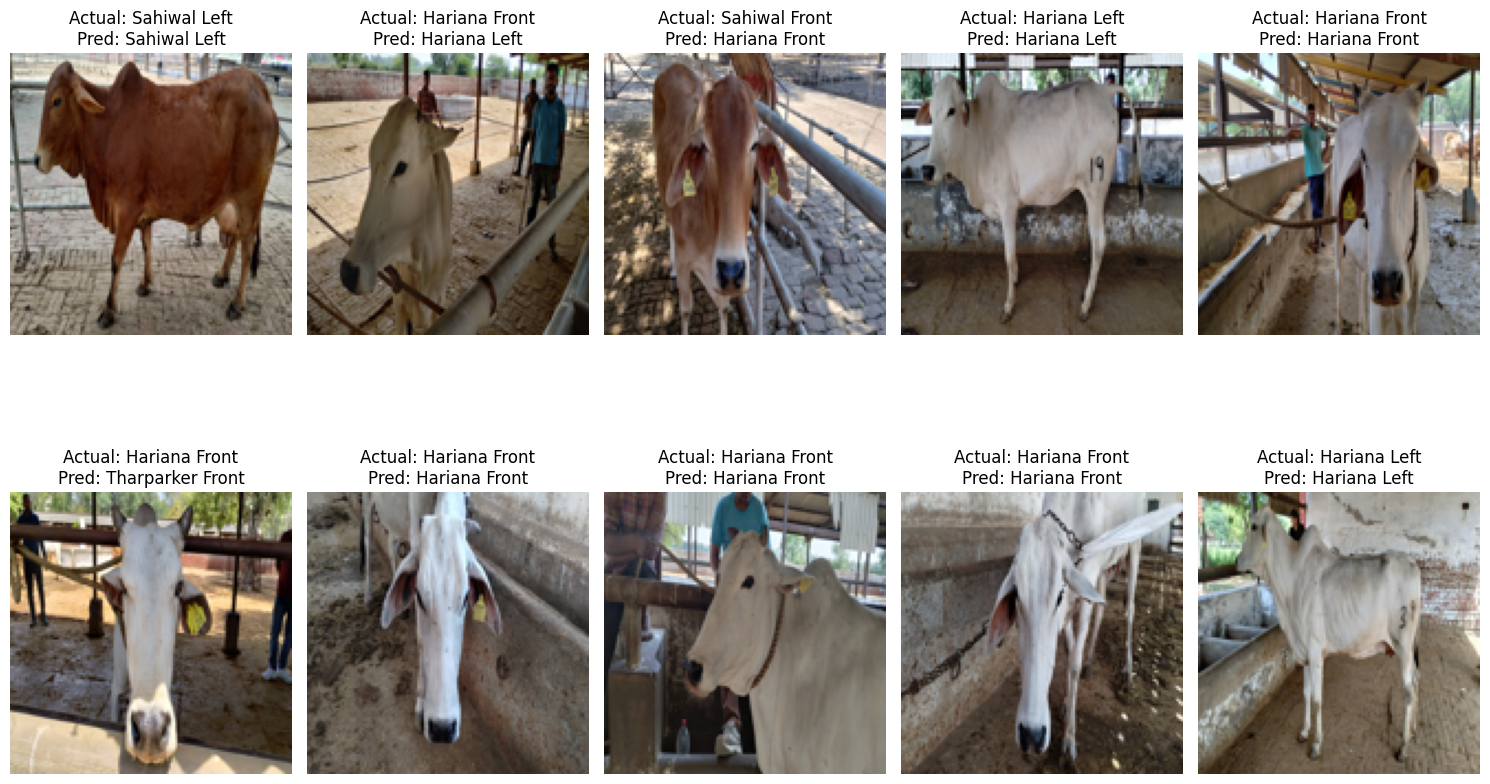

In [1]:
# -*- coding: utf-8 -*-
# PCA + KNN Image Classification Model

import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load Dataset
# =========================

image_dataset_path = '/content/drive/MyDrive/Research_Work/Dr Indu Lathwal/Dataset/'
output_filename = 'preprocessed_image_dataset.npz'
full_output_path = os.path.join(image_dataset_path, output_filename)

loaded_data = np.load(full_output_path)
loaded_images = loaded_data['images']
loaded_labels = loaded_data['labels']

print(f"Loaded images shape: {loaded_images.shape}")
print(f"Loaded labels shape: {loaded_labels.shape}")

# =========================
# Encode Labels
# =========================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(loaded_labels)

# =========================
# Train-Test Split
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    loaded_images,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

# =========================
# Flatten Images
# =========================

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened input shape:", X_train_flat.shape)

# =========================
# Apply PCA (Dimensionality Reduction)
# =========================

from sklearn.decomposition import PCA

# Reduce to 150 principal components (adjust if needed)
pca = PCA(n_components=150, random_state=42)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("PCA reduced shape:", X_train_pca.shape)
print("Explained variance ratio:", np.sum(pca.explained_variance_ratio_))

# =========================
# Train KNN Model
# =========================

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn_model.fit(X_train_pca, y_train)

print("KNN training complete.")

# =========================
# Evaluate Model
# =========================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = knn_model.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# =========================
# Plot PCA Explained Variance
# =========================

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), linewidth=3)
plt.title("Cumulative Explained Variance by PCA", fontsize=20, fontweight='bold')
plt.xlabel("Number of Components", fontsize=18)
plt.ylabel("Cumulative Explained Variance", fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# =========================
# Visualize Sample Predictions
# =========================

num_samples_to_show = 10
random_indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

sampled_images = X_test[random_indices]
sampled_images_flat = sampled_images.reshape(sampled_images.shape[0], -1)
sampled_images_pca = pca.transform(sampled_images_flat)

sampled_true_labels = y_test[random_indices]
sampled_predicted_labels = knn_model.predict(sampled_images_pca)

sampled_true_class_names = label_encoder.inverse_transform(sampled_true_labels)
sampled_predicted_class_names = label_encoder.inverse_transform(sampled_predicted_labels)

plt.figure(figsize=(15, 10))
for i in range(num_samples_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sampled_images[i])
    plt.title(f"Actual: {sampled_true_class_names[i]}\nPred: {sampled_predicted_class_names[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()